In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler    
import seaborn as sns
from tmdbv3api import TMDb, Movie
from tqdm import tqdm
import plotly.express as px
import os
from dotenv import load_dotenv

In [8]:
df_links = pd.read_csv('links.csv')
df_movies = pd.read_csv('movies.csv')
df_ratings = pd.read_csv('ratings.csv')
df_tags = pd.read_csv('tags.csv')
len(df_ratings)


100836

In [9]:
print(len(df_links))
len(df_movies)

9742


9742

In [10]:
def head(df):
    return df.head()

def isnull(df):
    return df.isnull().sum()

print(head(df_links))
print(head(df_movies))
print(head(df_ratings))
head(df_tags)

   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [11]:
print(isnull(df_links))
print(isnull(df_movies))
print(isnull(df_ratings))
print(isnull(df_tags))

movieId    0
imdbId     0
tmdbId     8
dtype: int64
movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64


In [15]:
#pip install tmdbv3api
load_dotenv()   

True

In [14]:
tmdb = TMDb()
tmdb.api_key = os.getenv("TMDB_API_KEY")
tmdb.language = 'fr'
movie_api = Movie()
enriched_data = []

first_valid_row = df_links.dropna(subset=['tmdbId']).iloc[0]
tmdb_id = int(first_valid_row['tmdbId'])
m = movie_api.details(int(tmdb_id))
print(m.__dict__.keys())

dict_keys(['_json', '_key', '_dict_key', '_dict_key_name', '_obj_list', '_list_only', 'adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'origin_country', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count', 'videos', 'trailers', 'images', 'casts', 'translations', 'keywords', 'release_dates'])


on enrichit les données avec l'API TMDb pour avoir du contexte. 'links.csv' contient seulement les caractéristiques 'movieId','imdbId','tmdbId'

In [16]:
""""
for index, row in tqdm(df_links.iterrows(), total = df_links.shape[0]):
    tmdb_id = row['tmdbId']
    
    if pd.isna(tmdb_id):
        enriched_data.append({})
        continue
    
    try:
        m = movie_api.details(int(tmdb_id))
        enriched_data.append({
            'movieId': row['movieId'], 
            'budget': getattr(m, 'budget', 0),
            'revenue': getattr(m, 'revenue', 0),
            'runtime': getattr(m, 'runtime', 0),
            'release_date': getattr(m, 'release_date', np.nan),
            'vote_average_tmdb': getattr(m, 'vote_average', 0),
            'vote_count_tmdb': getattr(m, 'vote_count', 0)
        })
        
    except Exception as e:
        enriched_data.append({'movieId': row['movieId']})
        
df_enriched = pd.DataFrame(enriched_data)
df_enriched.to_csv('movies_enriched.csv', index = False)
df_meta = pd.read_csv('movies_enriched.csv')
"""

'"\nfor index, row in tqdm(df_links.iterrows(), total = df_links.shape[0]):\n    tmdb_id = row[\'tmdbId\']\n    \n    if pd.isna(tmdb_id):\n        enriched_data.append({})\n        continue\n    \n    try:\n        m = movie_api.details(int(tmdb_id))\n        enriched_data.append({\n            \'movieId\': row[\'movieId\'], \n            \'budget\': getattr(m, \'budget\', 0),\n            \'revenue\': getattr(m, \'revenue\', 0),\n            \'runtime\': getattr(m, \'runtime\', 0),\n            \'release_date\': getattr(m, \'release_date\', np.nan),\n            \'vote_average_tmdb\': getattr(m, \'vote_average\', 0),\n            \'vote_count_tmdb\': getattr(m, \'vote_count\', 0)\n        })\n        \n    except Exception as e:\n        enriched_data.append({\'movieId\': row[\'movieId\']})\n        \ndf_enriched = pd.DataFrame(enriched_data)\ndf_enriched.to_csv(\'movies_enriched.csv\', index = False)\ndf_meta = pd.read_csv(\'movies_enriched.csv\')\n'

In [17]:
df_meta = pd.read_csv('movies_enriched.csv')
df_meta.columns


Index(['movieId', 'budget', 'revenue', 'runtime', 'release_date',
       'vote_average_tmdb', 'vote_count_tmdb'],
      dtype='str')

In [18]:
df_ratings_sumup = df_ratings.groupby('movieId').agg({'rating' : ['mean', 'count', 'std']})
df_ratings_sumup = df_ratings_sumup.reset_index()
df_ratings_sumup.columns = ['movieId', 'mean_rating', 'num_votes', 'std_rating']


In [19]:
df_ratings_sumup.head()

,movieId,mean_rating,num_votes,std_rating
0,1,3.920930,215,0.834859
1,2,3.431818,110,0.881713
2,3,3.259615,52,1.054823
3,4,2.357143,7,0.852168
4,5,3.071429,49,0.907148


In [20]:
len(df_ratings_sumup)

9724

In [21]:
df_tags['tag'] = df_tags['tag'].astype(str)
df_tags_sumup = df_tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()
df_tags_sumup.columns = ['movieId', 'all_tags']

In [22]:
df_final = df_movies.merge(df_meta, on = 'movieId', how = 'left')
df_final = df_final.merge(df_ratings_sumup, on = 'movieId', how = 'left')
df_final = df_final.merge(df_tags_sumup,on = 'movieId', how = 'left')
print(df_final.columns)
print(df_final.head())
print(len(df_final))

Index(['movieId', 'title', 'genres', 'budget', 'revenue', 'runtime',
       'release_date', 'vote_average_tmdb', 'vote_count_tmdb', 'mean_rating',
       'num_votes', 'std_rating', 'all_tags'],
      dtype='str')
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres      budget      revenue  \
0  Adventure|Animation|Children|Comedy|Fantasy  30000000.0  401157969.0   
1                   Adventure|Children|Fantasy  65000000.0  262821940.0   
2                               Comedy|Romance  25000000.0   71500000.0   
3                         Comedy|Drama|Romance  16000000.0   81452156.0   
4                                       Comedy         0.0   76594107.0   

   runtime release_date  vote_avera

In [23]:
df_final.to_csv('df_final.csv', index = True)

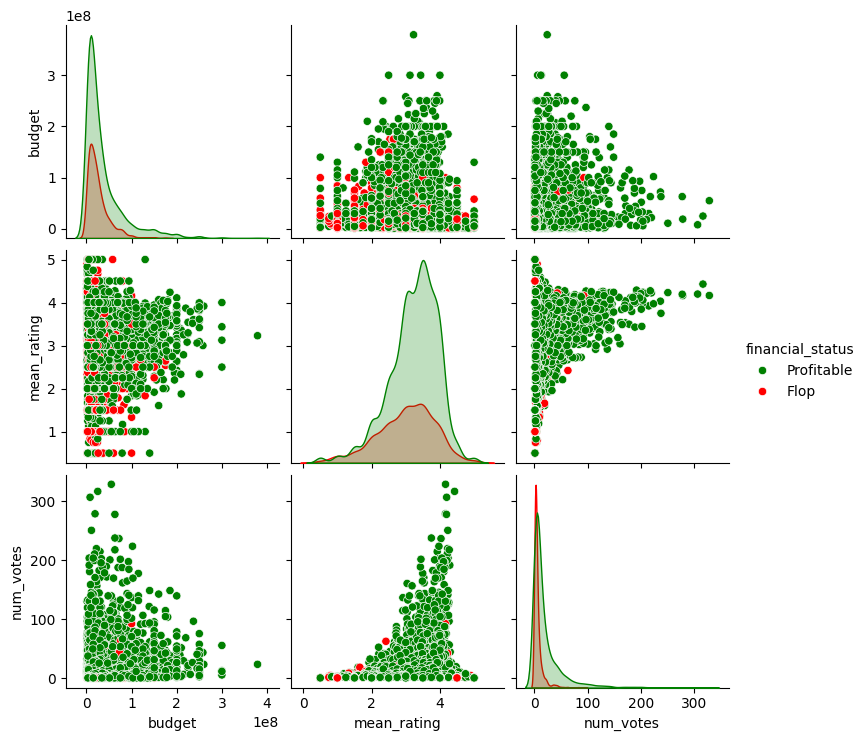

In [24]:
df_roi = df_final[(df_final['budget'] > 1000000) & (df_final['revenue'] > 0)].copy()
df_roi['financial_status'] = df_roi.apply(lambda x: 'Profitable' if x['revenue'] > x['budget'] else 'Flop', axis=1)

sns.pairplot(df_roi, 
             vars=['budget', 'mean_rating', 'num_votes'], 
             hue='financial_status',
             palette={'Profitable': 'green', 'Flop': 'red'})
plt.show()

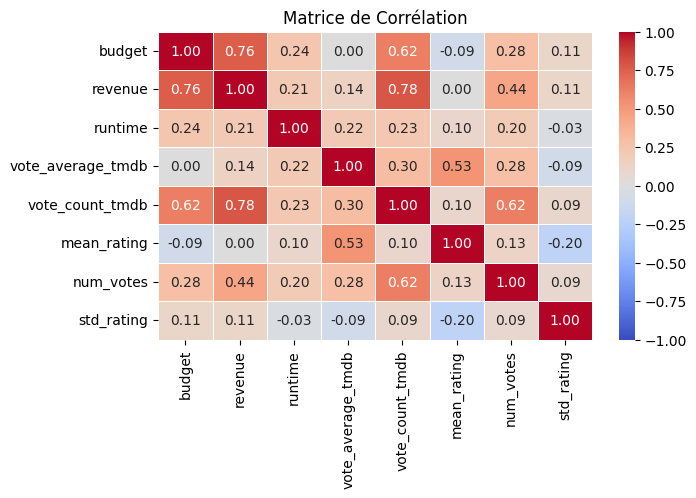

In [25]:
cols_to_corr = df_final.select_dtypes(include=['float64', 'int64']).drop(columns=['movieId'], errors='ignore')

plt.figure(figsize=(7, 4))

sns.heatmap(cols_to_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

plt.title('Matrice de Corrélation')
plt.show()

T-SNE

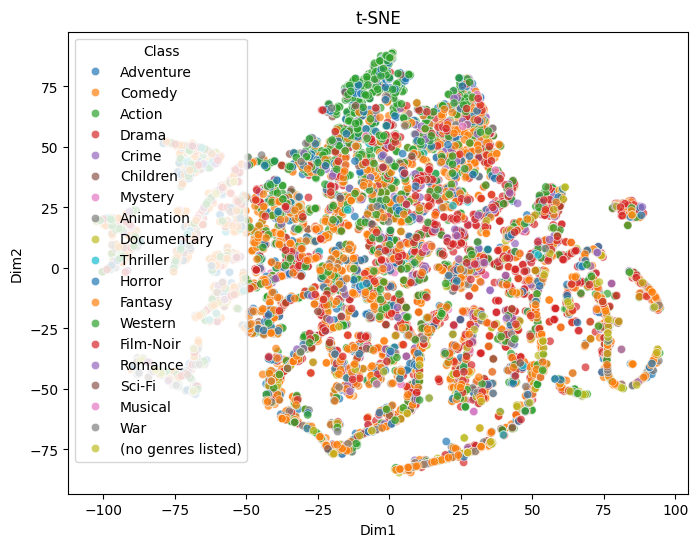

In [26]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer

X_num = df_final[['budget', 'revenue', 'mean_rating', 'num_votes', 'runtime']].fillna(0).values
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
tfidf = TfidfVectorizer(max_features=100, stop_words='english') 
X_text = tfidf.fit_transform(df_final['all_tags'].fillna(''))

X_combined = hstack([X_num_scaled, X_text])
tsne = TSNE(n_components=2, perplexity=30, init='random', learning_rate='auto')
X_embedded = tsne.fit_transform(X_combined)
df_tsne = pd.DataFrame(X_embedded, columns=['Dim1', 'Dim2'])
df_tsne['Class'] = df_final['genres'].str.split('|').str[0].values
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_tsne,x='Dim1', y='Dim2', hue='Class', palette='tab10',alpha=0.7)
plt.title('t-SNE')
plt.show()

In [27]:
fig = px.scatter(df_tsne, x = 'Dim1', y= 'Dim2', color= 'Class')
fig.update_layout(
    title="T-SNE visualization",
    xaxis_title="Dimension 1",
    yaxis_title="Dimension 2",
)
fig.show()

PCA

In [28]:
pca = PCA(n_components = 2)
scaler = StandardScaler()
y = df_tsne['Class']
X_pca = pca.fit_transform(X_combined)
fig_pca = px.scatter(x = X_pca[:,0], y =X_pca[:,1], color = y)
fig_pca.update_layout(
    title="PCA visualization of Custom Classification dataset",
    xaxis_title="First Principal Component",
    yaxis_title="Second Principal Component",
)
fig_pca.show()


ISOMAP

In [ ]:
embedding = Isomap(n_components = 2, n_neighbors= 30)
X_isomap = embedding.fit_transform(X_num_scaled)
fig_iso = px.scatter( x = X_isomap[:,0], y =X_isomap[:,1], color = y, opacity = 0.7, title = 'Isomap Projection')
fig_iso.show()

LocallyLinearEmbedding (LLE)

In [29]:
embedding = LocallyLinearEmbedding(n_components = 2)
X_transformed = embedding.fit_transform(X_num_scaled)
fig_lle = px.scatter( x = X_transformed[:,0], y =X_transformed[:,1], color = y, opacity = 0.7, title = 'LLE Projection')
fig_lle.show()

Self Organizing Map

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.7315843242344683


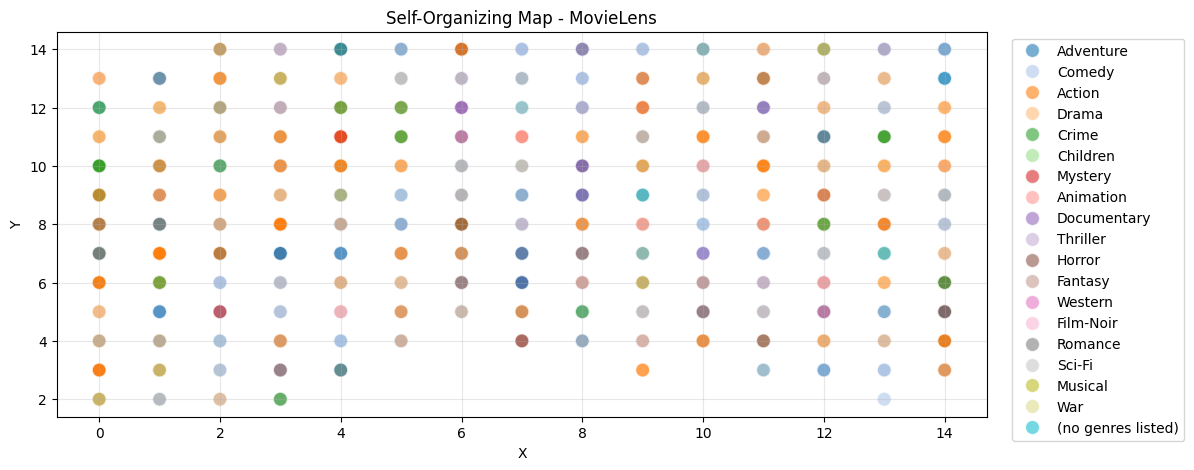

In [30]:
from minisom import MiniSom

X_dense = X_combined.toarray()
som = MiniSom(x =15,y = 15, input_len = X_dense.shape[1],sigma = 1.5, learning_rate = 0.5, random_seed = 42)
som.train_random(X_dense, num_iteration = 1000, verbose = True)
som_coords = np.array([som.winner(x) for x in X_dense])

df_som = pd.DataFrame(som_coords, columns=['X', 'Y'])
df_som['Class'] = df_final['genres'].str.split('|').str[0].values

plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_som, x='X', y='Y', hue='Class', palette='tab20', s=100, alpha=0.6)
plt.title('Self-Organizing Map - MovieLens')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

Les points sont superposés les uns sur les autres donc on rajoute du bruit sur les coordonnées pour visualiser correctement.

 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.5629650576562405


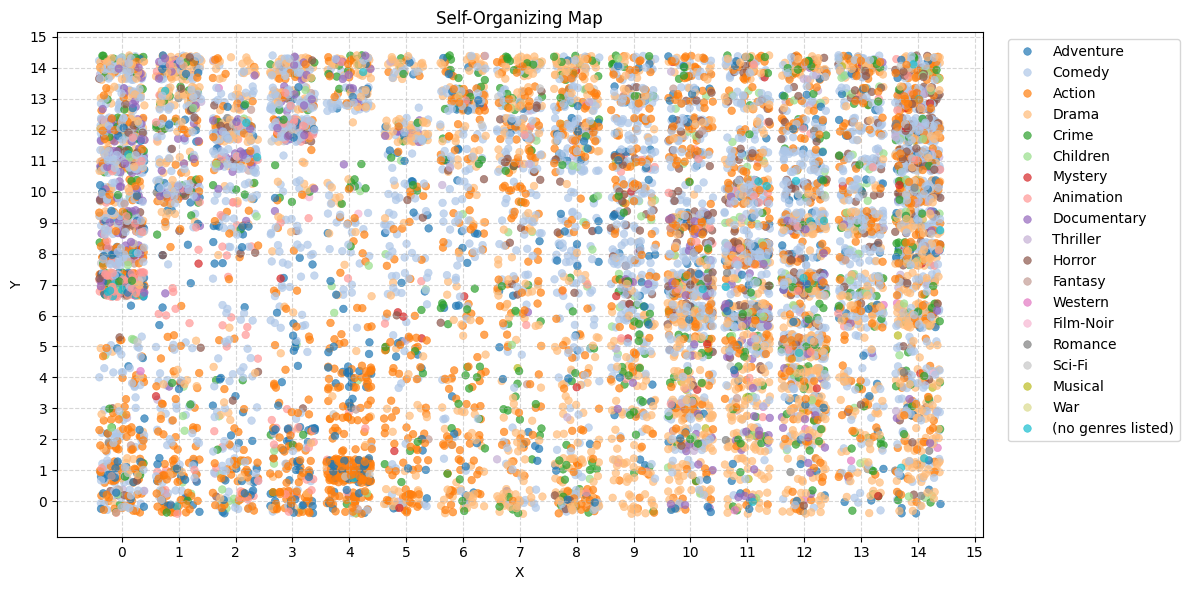

In [31]:
X_dense = X_combined.toarray()

som = MiniSom(x=15, y=15, input_len=X_dense.shape[1], sigma=1.5, learning_rate=0.5, random_seed=42)
som.train_random(X_dense, num_iteration=5000, verbose=True)

winners = np.array([som.winner(x) for x in X_dense])

jitter_x = np.random.rand(len(winners)) - 0.5
jitter_y = np.random.rand(len(winners)) - 0.5

df_som = pd.DataFrame()
df_som['X'] = winners[:, 0] + jitter_x * 0.8
df_som['Y'] = winners[:, 1] + jitter_y * 0.8
df_som['Class'] = df_final['genres'].str.split('|').str[0].values

plt.figure(figsize=(12, 6))
plt.xticks(np.arange(16))
plt.yticks(np.arange(16))
plt.grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df_som,x='X',y='Y',hue='Class',palette='tab20',s=30,alpha=0.7,edgecolor=None)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('Self-Organizing Map')
plt.tight_layout()
plt.show()

In [32]:
df_final_genre = df_final.copy()
df_final_genre['genres'] = df_final['genres'].str.split('|').str[0].values
df_final_genre.to_csv('df_final_genre.csv', index = False)

Kmeans

<Axes: xlabel='Dim1', ylabel='Dim2'>

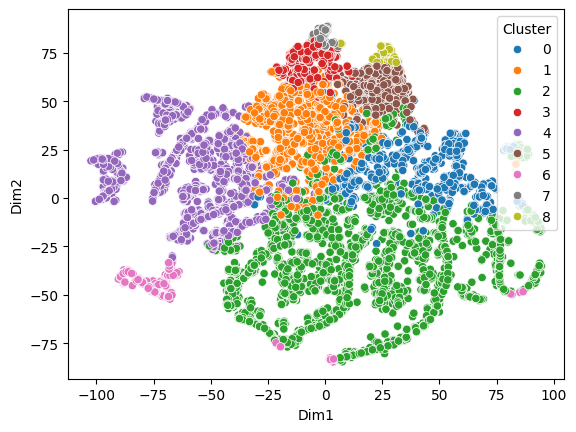

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_combined.toarray())
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_combined.toarray(), labels))
df_tsne['Cluster'] = labels
sns.scatterplot(data=df_tsne, x='Dim1', y='Dim2', hue='Cluster', palette='tab10')



In [34]:
import networkx as nx
import plotly.graph_objects as go

df = pd.read_csv('df_final.csv')
df_sample = df.nlargest(500, 'num_votes').reset_index(drop=True)

G = nx.Graph()

for _, row in df_sample.iterrows():
    film_node = f"film_{row['movieId']}"
    G.add_node(film_node, 
               type='film', 
               title=row['title'],
               rating=round(row['mean_rating'], 2),
               genres=row['genres'])
    
    genres = str(row['genres']).split('|')
    for genre in genres:
        if genre not in G.nodes:
            G.add_node(genre, type='genre', title=genre)
        G.add_edge(film_node, genre)


film_nodes  = [n for n, d in G.nodes(data=True) if d['type'] == 'film']
genre_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'genre']

pos = nx.spring_layout(G, seed=42, k=0.8)

edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode='lines',
    line=dict(width=0.5, color='rgba(180,180,180,0.3)'),
    hoverinfo='none',
    showlegend=False
)

film_x, film_y, film_hover, film_sizes = [], [], [], []

for node in film_nodes:
    x, y = pos[node]
    film_x.append(x)
    film_y.append(y)
    film_sizes.append(6 + G.degree(node) * 1.5) 
    film_hover.append(
        f"<b>{G.nodes[node]['title']}</b><br>"
        f"Genres : {G.nodes[node]['genres'].replace('|', ' | ')}<br>"
        f"Rating : {G.nodes[node]['rating']}"
    )

film_trace = go.Scatter(
    x=film_x, y=film_y,
    mode='markers',
    name='Films',
    hovertext=film_hover,
    hoverinfo='text',
    marker=dict(
        size=film_sizes,
        color='#4e9af1',
        opacity=0.7,
        line=dict(width=0.5, color='white')
    )
)

genre_colors = {
    'Action':'#e74c3c',     'Adventure':'#e67e22',  'Animation':'#f1c40f',
    'Children':'#2ecc71',   'Comedy':'#1abc9c',      'Crime':'#9b59b6',
    'Documentary':'#34495e','Drama':'#e91e63',        'Fantasy':'#00bcd4',
    'Film-Noir':'#607d8b',  'Horror':'#c0392b',       'Mystery':'#8e44ad',
    'Romance':'#ff69b4',    'Thriller':'#d35400',     'Western':'#795548'
}

genre_x, genre_y, genre_text, genre_hover, genre_color_list = [], [], [], [], []

for node in genre_nodes:
    x, y = pos[node]
    genre_x.append(x)
    genre_y.append(y)
    genre_text.append(node)
    genre_color_list.append(genre_colors.get(node, '#aaaaaa'))
    genre_hover.append(
        f"<b>Genre : {node}</b><br>"
        f"Nombre de films : {G.degree(node)}"
    )

genre_trace = go.Scatter(
    x=genre_x, y=genre_y,
    mode='markers+text',
    name='Genres',
    text=genre_text,
    textposition='top center',
    textfont=dict(size=11, color='white'),
    hovertext=genre_hover,
    hoverinfo='text',
    marker=dict(
        size=[20 + G.degree(n) * 1.5 for n in genre_nodes], 
        color=genre_color_list,
        opacity=0.95,
        line=dict(width=2, color='white')
    )
)

fig = go.Figure(
    data=[edge_trace, film_trace, genre_trace],
    layout=go.Layout(
        title=dict(text='Graphe Bipartite Films ↔ Genres', font=dict(size=18, color='white')),
        showlegend=True,
        hovermode='closest',
        plot_bgcolor='#0f0f1a',
        paper_bgcolor='#0f0f1a',
        font=dict(color='white'),
        height=800,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        legend=dict(
            bgcolor='rgba(255,255,255,0.1)',
            bordercolor='white',
            borderwidth=1
        )
    )
)

fig.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

# ── 1. Encoder les genres de chaque film en vecteur binaire ───
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(
    df_sample['genres'].str.split('|')
)

# ── 2. KMeans pour regrouper les films similaires ──────────────
N_CLUSTERS = 6  # ajustez selon vos besoins
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_sample['cluster'] = km.fit_predict(genre_matrix)

# Nommer chaque cluster par ses genres dominants
def cluster_label(cluster_id):
    films_in_cluster = df_sample[df_sample['cluster'] == cluster_id]
    all_genres = films_in_cluster['genres'].str.split('|').explode()
    top_genres = all_genres.value_counts().head(2).index.tolist()
    return ' / '.join(top_genres)

cluster_names = {i: cluster_label(i) for i in range(N_CLUSTERS)}

# ── 3. Construction du graphe summarisé ───────────────────────
G_summary = nx.Graph()

# Ajouter les super-noeuds (clusters de films)
for cluster_id in range(N_CLUSTERS):
    films_in_cluster = df_sample[df_sample['cluster'] == cluster_id]
    avg_rating = round(films_in_cluster['mean_rating'].mean(), 2)
    
    G_summary.add_node(f"cluster_{cluster_id}",
                       type='cluster',
                       label=cluster_names[cluster_id],
                       size=len(films_in_cluster),
                       avg_rating=avg_rating,
                       films=films_in_cluster['title'].tolist())

# Ajouter les noeuds genres
for genre in genre_nodes:
    G_summary.add_node(genre, type='genre', title=genre)

# Ajouter les liens cluster → genre (avec poids = nb de films)
for cluster_id in range(N_CLUSTERS):
    films_in_cluster = df_sample[df_sample['cluster'] == cluster_id]
    genre_counts = (films_in_cluster['genres']
                    .str.split('|').explode()
                    .value_counts())
    
    for genre, count in genre_counts.items():
        if genre in G_summary.nodes:
            G_summary.add_edge(f"cluster_{cluster_id}", genre, weight=count)

# ── 4. Layout et visualisation ─────────────────────────────────
pos_summary = nx.spring_layout(G_summary, seed=42, k=1.2)

cluster_colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD']

# Edges avec épaisseur proportionnelle au poids
edge_traces_summary = []
for u, v, data in G_summary.edges(data=True):
    x0, y0 = pos_summary[u]
    x1, y1 = pos_summary[v]
    edge_traces_summary.append(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode='lines',
        line=dict(width=data['weight'] * 0.3, color='rgba(200,200,200,0.4)'),
        hoverinfo='none',
        showlegend=False
    ))

# Noeuds clusters (super-noeuds)
cluster_nodes_list = [n for n, d in G_summary.nodes(data=True) if d['type'] == 'cluster']
cx, cy, c_text, c_hover, c_sizes, c_colors = [], [], [], [], [], []

for i, node in enumerate(cluster_nodes_list):
    x, y = pos_summary[node]
    d = G_summary.nodes[node]
    cx.append(x)
    cy.append(y)
    c_text.append(d['label'])
    c_sizes.append(30 + d['size'] * 3)
    c_colors.append(cluster_colors[i % len(cluster_colors)])
    
    films_preview = '<br>'.join([f"• {f}" for f in d['films'][:5]])
    c_hover.append(
        f"<b>Cluster : {d['label']}</b><br>"
        f"Nombre de films : {d['size']}<br>"
        f"Rating moyen : {d['avg_rating']}<br><br>"
        f"Films (extrait) :<br>{films_preview}"
    )

cluster_trace_summary = go.Scatter(
    x=cx, y=cy,
    mode='markers+text',
    name='Clusters de films',
    text=c_text,
    textposition='bottom center',
    textfont=dict(size=10, color='white'),
    hovertext=c_hover,
    hoverinfo='text',
    marker=dict(size=c_sizes, color=c_colors, opacity=0.85,
                line=dict(width=2, color='white'),
                symbol='diamond')  # ← forme différente pour distinguer
)

# Noeuds genres (identiques à avant)
gx, gy, g_text, g_hover, g_colors_s = [], [], [], [], []
genre_nodes_summary = [n for n, d in G_summary.nodes(data=True) if d['type'] == 'genre']

for node in genre_nodes_summary:
    x, y = pos_summary[node]
    gx.append(x)
    gy.append(y)
    g_text.append(node)
    g_colors_s.append(genre_colors.get(node, '#aaaaaa'))
    g_hover.append(f"<b>Genre : {node}</b><br>Connexions : {G_summary.degree(node)}")

genre_trace_summary = go.Scatter(
    x=gx, y=gy,
    mode='markers+text',
    name='Genres',
    text=g_text,
    textposition='top center',
    textfont=dict(size=11, color='white'),
    hovertext=g_hover,
    hoverinfo='text',
    marker=dict(
        size=[15 + G_summary.degree(n) * 2 for n in genre_nodes_summary],
        color=g_colors_s, opacity=0.95,
        line=dict(width=2, color='white')
    )
)

# ── 5. Figure finale ───────────────────────────────────────────
fig_summary = go.Figure(
    data=edge_traces_summary + [cluster_trace_summary, genre_trace_summary],
    layout=go.Layout(
        title=dict(text='Graph Summarization : Clusters de Films ↔ Genres',
                   font=dict(size=18, color='white')),
        plot_bgcolor='#0f0f1a',
        paper_bgcolor='#0f0f1a',
        font=dict(color='white'),
        height=800,
        hovermode='closest',
        showlegend=True,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    )
)

fig_summary.show()
